In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

DATA_DIR  = Path("/content/drive/MyDrive/data-20261002T094809Z-1-001/data")
IMAGE_DIR = DATA_DIR / "images"
LABEL_DIR = DATA_DIR / "labels"

In [ ]:
import os, re, random, time, json, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import rasterio
from rasterio.errors import NotGeoreferencedWarning

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, RandomSampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

## image–label pairing

In [ ]:
image_files = sorted(IMAGE_DIR.glob("*.tif"))
label_files = sorted(LABEL_DIR.glob("*.png"))
print(f"Images: {len(image_files)} | Label files: {len(label_files)}")

def extract_id(path):
    m = re.match(r"(\d+)", path.stem)
    return int(m.group(1)) if m else None

image_by_id = {extract_id(p): p for p in image_files if extract_id(p) is not None}
labels_by_id = defaultdict(list)
for p in label_files:
    i = extract_id(p)
    if i is not None:
        labels_by_id[i].append(p)

def pick_primary(image_id, candidates):
    exact = [p for p in candidates if p.stem == str(image_id)]
    return exact[0] if exact else sorted(candidates)[0]

primary_label = {i: pick_primary(i, c) for i, c in labels_by_id.items()}

def load_mask(path):
    m = np.array(Image.open(path))
    if m.ndim == 3:
        m = m.max(axis=-1)
    return (m > 0).astype(np.uint8)

vals = set()
for p in primary_label.values():
    vals |= set(np.unique(np.array(Image.open(p))).tolist())
print("Distinct raw label values:", sorted(vals), "(binarised with value > 0 -> water)")

audit = []
for image_id, paths in sorted(labels_by_id.items()):
    prim = primary_label[image_id]
    mp = load_mask(prim)
    for p in paths:
        if p == prim:
            continue
        m = load_mask(p)
        same = m.shape == mp.shape
        audit.append(dict(id=image_id, primary=prim.name, duplicate=p.name,
                          same_shape=same,
                          pixel_agreement=float((m == mp).mean()) if same else np.nan,
                          water_frac_primary=float(mp.mean()),
                          water_frac_duplicate=float(m.mean())))
audit_df = pd.DataFrame(audit)
if len(audit_df):
    print(f"\n{len(audit_df)} duplicate label files. Pixel agreement with the primary label: "
          f"min={audit_df.pixel_agreement.min():.3f}, mean={audit_df.pixel_agreement.mean():.3f}")
    display(audit_df.head(8))
    if audit_df.pixel_agreement.min() < 0.99:
        print("WARNING: some duplicates differ from the primary label -> ask which annotation is the reference.")
else:
    print("No duplicate labels.")

pairs = [dict(id=i, image=image_by_id[i], label=primary_label[i])
         for i in sorted(image_by_id) if i in primary_label]
df = pd.DataFrame(pairs)
unlabeled_ids = sorted(i for i in image_by_id if i not in primary_label)
print(f"\nLabeled pairs: {len(df)} | images without any label: {len(unlabeled_ids)}")
assert len(df) > 0 and df["id"].is_unique

Images: 306 | Label files: 456
Distinct raw label values: [0, 1] (binarised with value > 0 -> water)

150 duplicate label files. Pixel agreement with the primary label: min=0.010, mean=0.499


,id,primary,duplicate,same_shape,pixel_agreement,water_frac_primary,water_frac_duplicate
0,1,1.png,1_226.png,True,0.011108,0.011108,1.000000
1,2,2.png,2_215.png,True,0.718262,0.718262,1.000000
2,3,3.png,3_74.png,True,0.053162,0.053162,1.000000
3,4,4.png,4_300.png,True,0.021606,0.019836,0.998230
4,5,5.png,5_275.png,True,0.009644,0.000000,0.990356
5,6,6.png,6_248.png,True,0.029724,0.017029,0.987305
6,7,7.png,7_146.png,True,0.015076,0.002319,0.986877
7,8,8.png,8_73.png,True,0.157837,0.151978,0.986328



Labeled pairs: 306 | images without any label: 0


In [ ]:
def load_multispectral(path):
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)

X_raw = np.stack([load_multispectral(p) for p in df["image"]])
Y     = np.stack([load_mask(p) for p in df["label"]]).astype(np.float32)
N = len(df)

# Define the missing constants
NUM_CHANNELS = X_raw.shape[1]
IMG_SIZE = X_raw.shape[2:]

assert X_raw.shape == (N, NUM_CHANNELS, *IMG_SIZE), X_raw.shape
assert Y.shape == (N, *IMG_SIZE), Y.shape
if np.isnan(X_raw).any():
    print("NaNs found -> replaced by 0"); X_raw = np.nan_to_num(X_raw)

df["water_fraction"] = Y.mean(axis=(1, 2))
frac = df["water_fraction"].values
print("X:", X_raw.shape, X_raw.dtype, "| Y:", Y.shape)
print(f"Global min/max: {X_raw.min():.0f} / {X_raw.max():.0f}")
print(f"Water pixels: {100*Y.mean():.1f}% of all labeled pixels | per-image range {100*frac.min():.1f}% – {100*frac.max():.1f}%")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


X: (306, 12, 128, 128) float32 | Y: (306, 128, 128)
Global min/max: -9999 / 15841
Water pixels: 26.0% of all labeled pixels | per-image range 0.0% – 100.0%


## 2. Exploratory checks

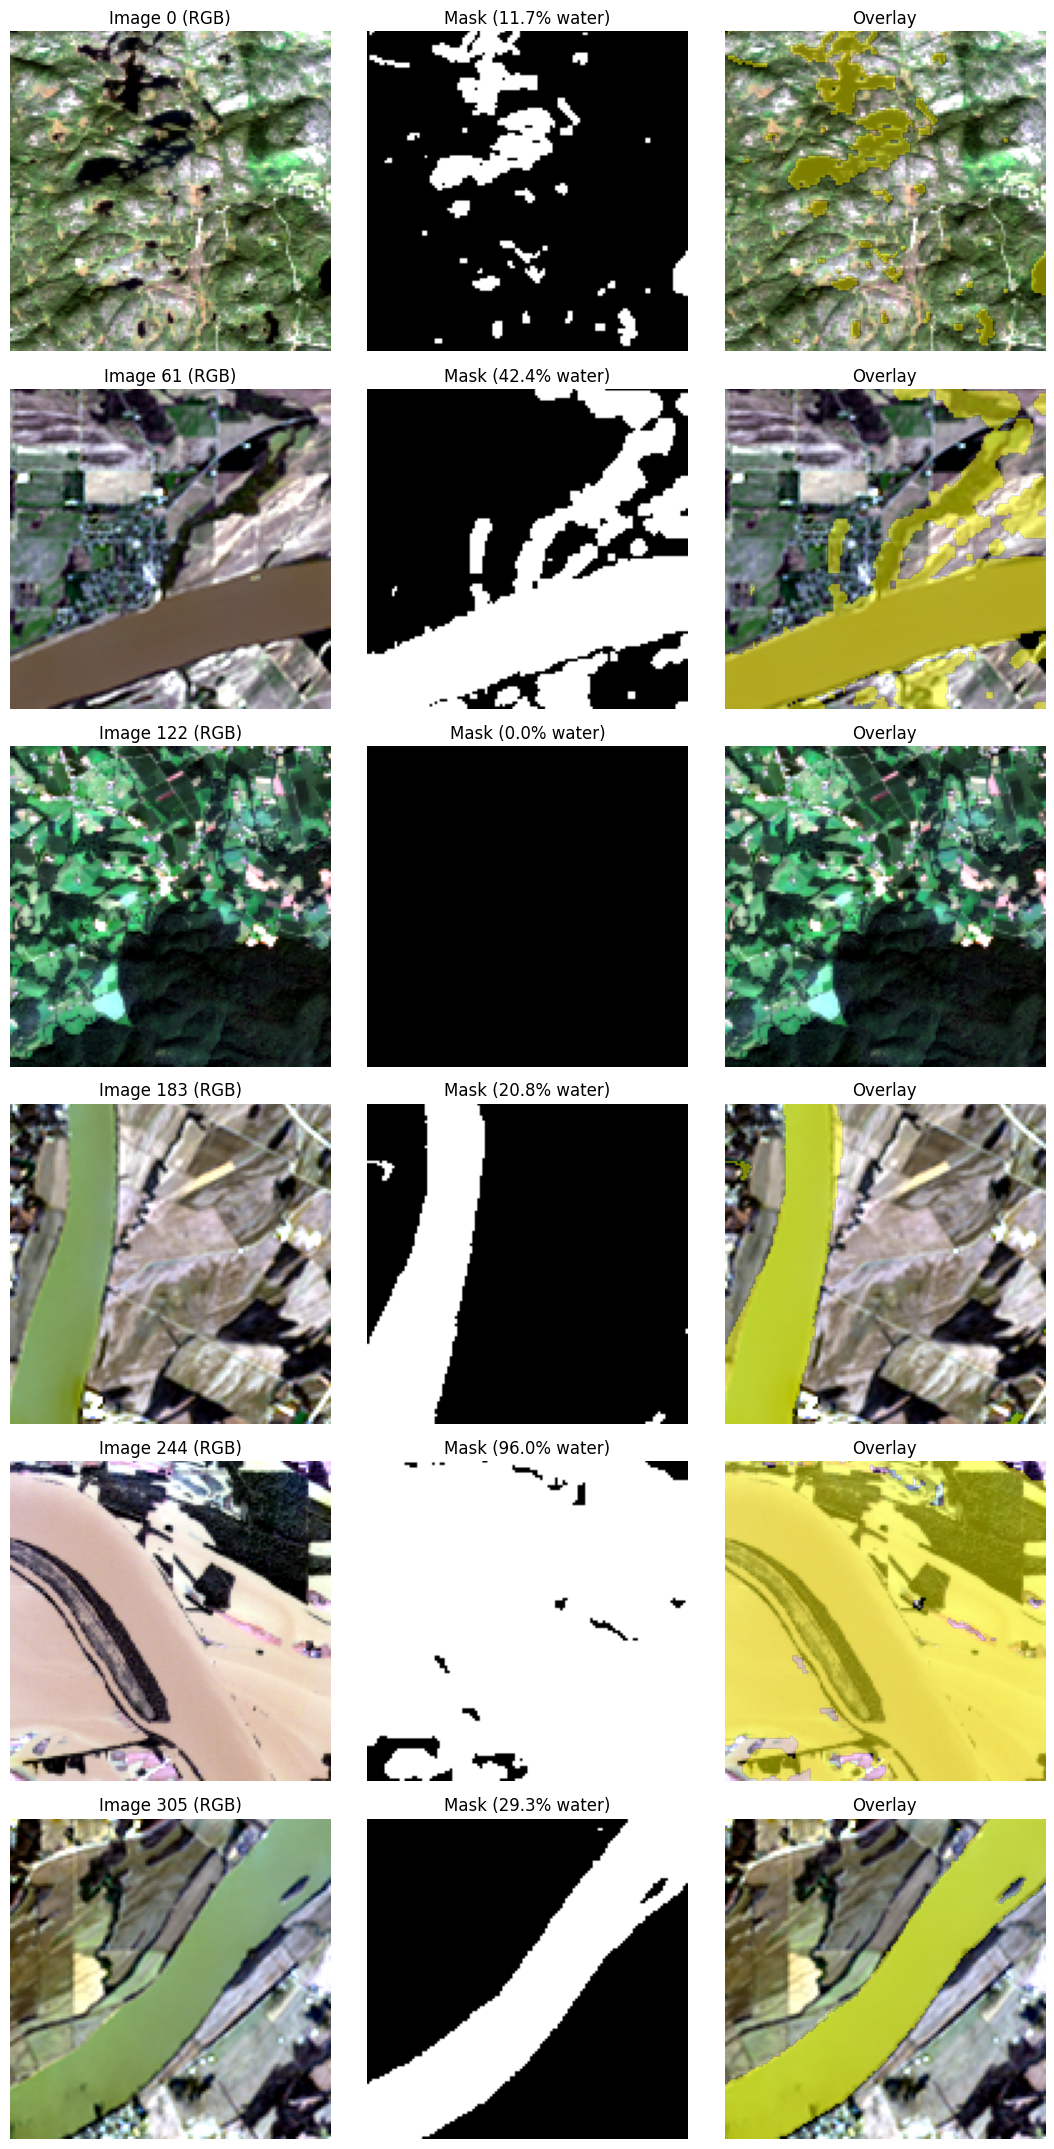

In [ ]:
def stretch(a, lo=2, hi=98):
    l, h = np.percentile(a, [lo, hi])
    return np.clip((a - l) / (h - l + 1e-6), 0, 1)

def composite(img, idx):
    return np.stack([stretch(img[i]) for i in idx], axis=-1)

TRUE_COLOR  = (3, 2, 1)   # Red, Green, Blue (channels 4,3,2)
FALSE_COLOR = (4, 3, 2)   # NIR, Red, Green  (channels 5,4,3)  vegetation = red, water = dark
SWIR_COLOR  = (5, 4, 3)   # SWIR1, NIR, Red  (channels 6,5,4)  water = black, built-up = blue/cyan

show = np.linspace(0, N - 1, min(6, N), dtype=int)
fig, axes = plt.subplots(len(show), 3, figsize=(11, 3.6 * len(show)))
for r, i in enumerate(show):
    rgb = composite(X_raw[i], TRUE_COLOR)
    axes[r, 0].imshow(rgb);                      axes[r, 0].set_title(f"Image {df.id[i]} (RGB)")
    axes[r, 1].imshow(Y[i], cmap="gray");        axes[r, 1].set_title(f"Mask ({100*frac[i]:.1f}% water)")
    axes[r, 2].imshow(rgb); axes[r, 2].imshow(np.ma.masked_equal(Y[i], 0), cmap="autumn", alpha=0.5, vmin=0, vmax=1)
    axes[r, 2].set_title("Overlay")
    for a in axes[r]: a.axis("off")
plt.tight_layout(); plt.show()

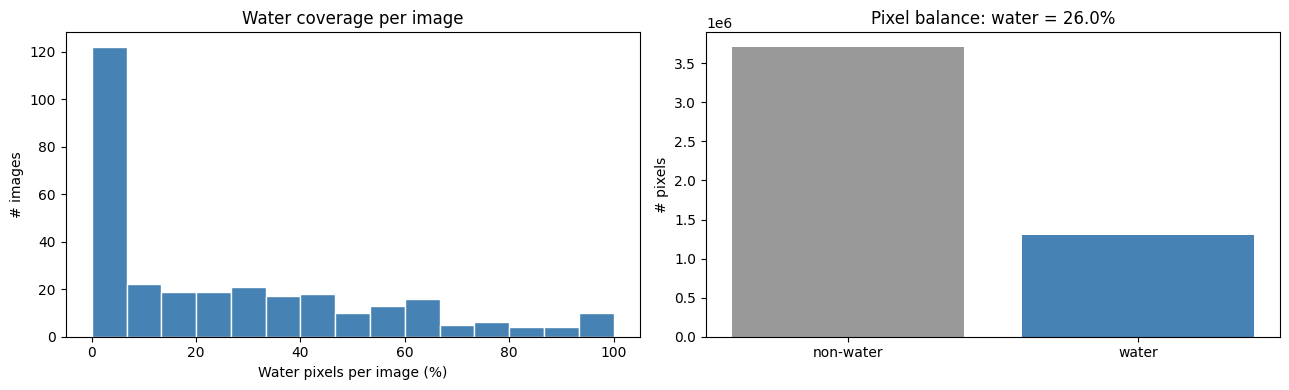

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(frac * 100, bins=15, color="steelblue", edgecolor="white")
ax[0].set_xlabel("Water pixels per image (%)"); ax[0].set_ylabel("# images"); ax[0].set_title("Water coverage per image")
ax[1].bar(["non-water", "water"], [(1 - Y).sum(), Y.sum()], color=["#999", "steelblue"])
ax[1].set_title(f"Pixel balance: water = {100*Y.mean():.1f}%"); ax[1].set_ylabel("# pixels")
plt.tight_layout(); plt.show()

In [ ]:
BAND_INFO = [
    {"ch": 1, "band": "Coastal Aerosol"},
    {"ch": 2, "band": "Blue"},
    {"ch": 3, "band": "Green"},
    {"ch": 4, "band": "Red"},
    {"ch": 5, "band": "NIR (Narrow)"},
    {"ch": 6, "band": "SWIR 1"},
    {"ch": 7, "band": "SWIR 2"},
    {"ch": 8, "band": "Aux 8"},
    {"ch": 9, "band": "Aux 9"},
    {"ch": 10, "band": "Aux 10"},
    {"ch": 11, "band": "Aux 11"},
    {"ch": 12, "band": "Aux 12"}
]

flat_X = X_raw.transpose(1, 0, 2, 3).reshape(NUM_CHANNELS, -1)
flat_y = Y.reshape(-1) > 0.5

w_mean, n_mean = flat_X[:, flat_y].mean(1), flat_X[:, ~flat_y].mean(1)
w_std,  n_std  = flat_X[:, flat_y].std(1),  flat_X[:, ~flat_y].std(1)
sep = np.abs(w_mean - n_mean) / np.sqrt((w_std**2 + n_std**2) / 2 + 1e-9)
auc_signed = np.array([roc_auc_score(flat_y, flat_X[c]) for c in range(NUM_CHANNELS)])

band_stats = pd.DataFrame({
    "Ch": np.arange(1, NUM_CHANNELS + 1),
    "Band": [b["band"] for b in BAND_INFO],
    "Water mean": w_mean, "Water std": w_std, "Non-water mean": n_mean, "Non-water std": n_std,
    "Water vs land": np.where(w_mean < n_mean, "darker", "brighter"),
    "Separation (d)": sep,
    "AUC (single band)": np.maximum(auc_signed, 1 - auc_signed),
}).round(2)
display(band_stats.sort_values("Separation (d)", ascending=False).reset_index(drop=True))

,Ch,Band,Water mean,Water std,Non-water mean,Non-water std,Water vs land,Separation (d),AUC (single band)
0,5,NIR (Narrow),962.320007,840.679993,2483.550049,808.320007,darker,1.84,0.89
1,6,SWIR 1,817.619995,1022.739990,2364.540039,961.460022,darker,1.56,0.86
2,7,SWIR 2,596.260010,772.549988,1615.349976,875.549988,darker,1.23,0.84
3,12,Aux 12,36.799999,44.230000,0.260000,2.880000,brighter,1.17,0.81
4,11,Aux 11,50.900002,26.330000,29.520000,13.630000,brighter,1.02,0.74
5,8,Aux 8,125.750000,52.980000,94.610001,44.830002,brighter,0.63,0.70
6,9,Aux 9,-439.160004,2431.050049,346.630005,543.799988,darker,0.45,0.71
7,10,Aux 10,154.970001,325.839996,351.950012,537.359985,darker,0.44,0.70
8,1,Coastal Aerosol,363.040009,194.910004,408.130005,290.200012,darker,0.18,0.54
9,2,Blue,479.329987,252.380005,500.100006,347.119995,darker,0.07,0.51


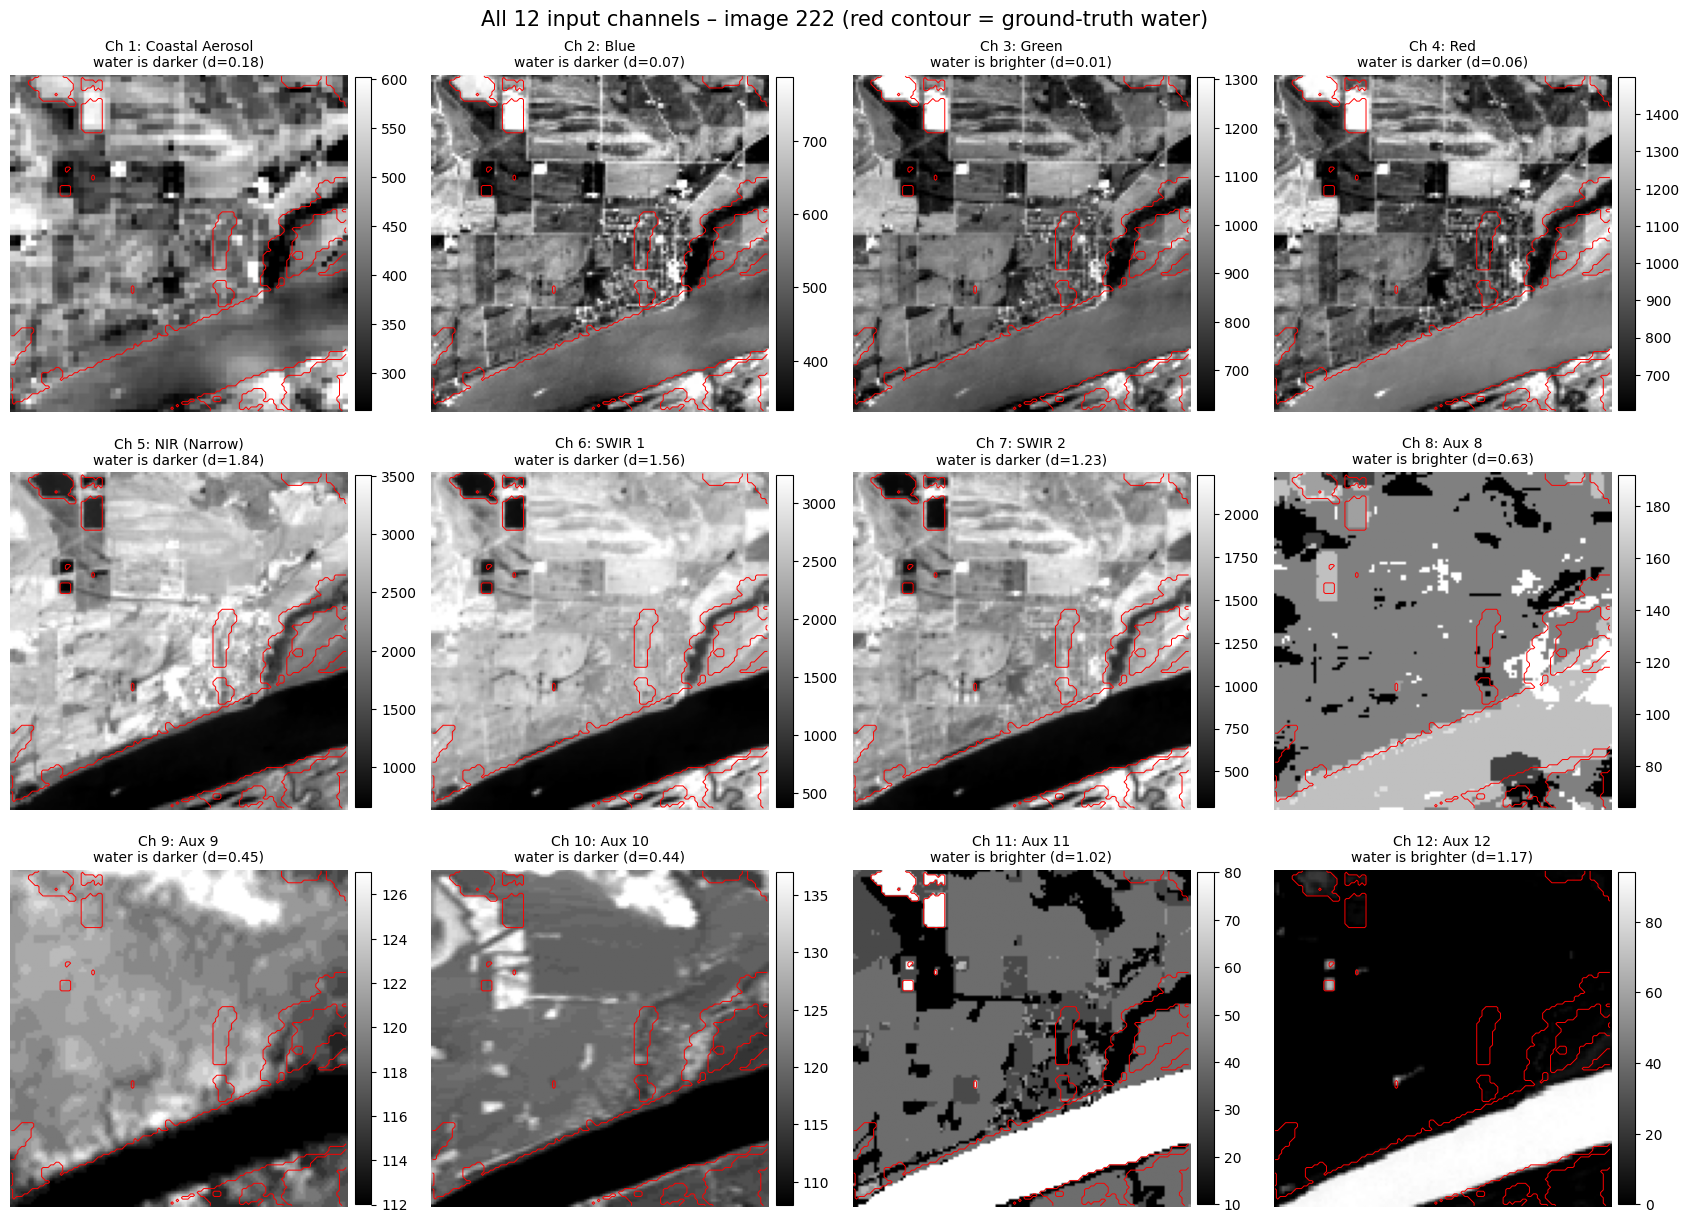

In [ ]:
rep = int(np.argmin(np.abs(frac - 0.30)))
img, msk = X_raw[rep], Y[rep]
short = [b["band"] if b["ch"] <= 7 else f"Aux {b['ch']}" for b in BAND_INFO]

fig, axes = plt.subplots(3, 4, figsize=(17, 12.5))
for c, ax in enumerate(axes.flat):
    lo, hi = np.percentile(img[c], [2, 98])
    im = ax.imshow(img[c], cmap="gray", vmin=lo, vmax=hi)
    if 0 < msk.mean() < 1:
        ax.contour(msk, levels=[0.5], colors="red", linewidths=0.7)
    ax.set_title(f"Ch {c+1}: {short[c]}\nwater is {band_stats['Water vs land'][c]} (d={sep[c]:.2f})", fontsize=10)
    ax.axis("off"); plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.suptitle(f"All 12 input channels – image {df.id[rep]} (red contour = ground-truth water)", fontsize=15)
plt.tight_layout(); plt.show()

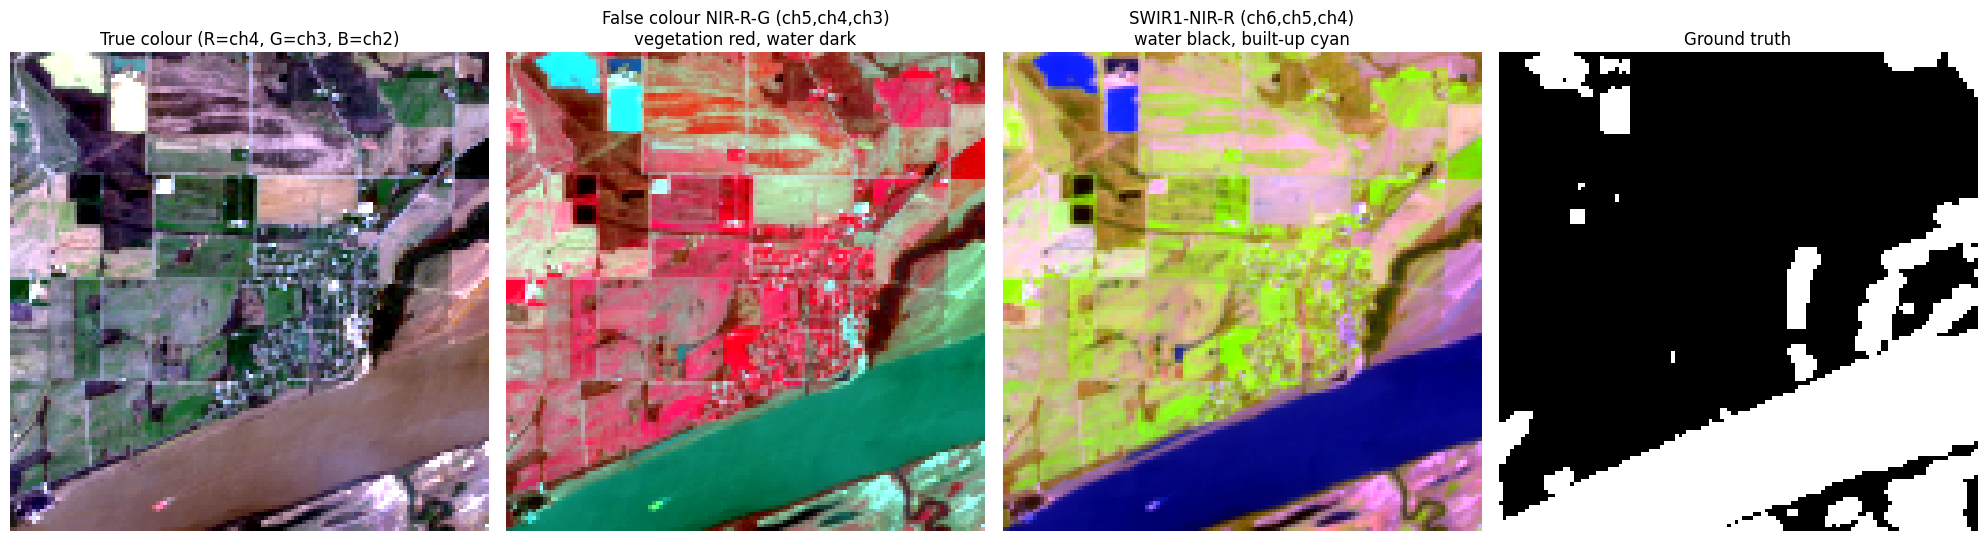

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5.2))
axes[0].imshow(composite(img, TRUE_COLOR));  axes[0].set_title("True colour (R=ch4, G=ch3, B=ch2)")
axes[1].imshow(composite(img, FALSE_COLOR)); axes[1].set_title("False colour NIR-R-G (ch5,ch4,ch3)\nvegetation red, water dark")
axes[2].imshow(composite(img, SWIR_COLOR));  axes[2].set_title("SWIR1-NIR-R (ch6,ch5,ch4)\nwater black, built-up cyan")
axes[3].imshow(msk, cmap="gray");            axes[3].set_title("Ground truth")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

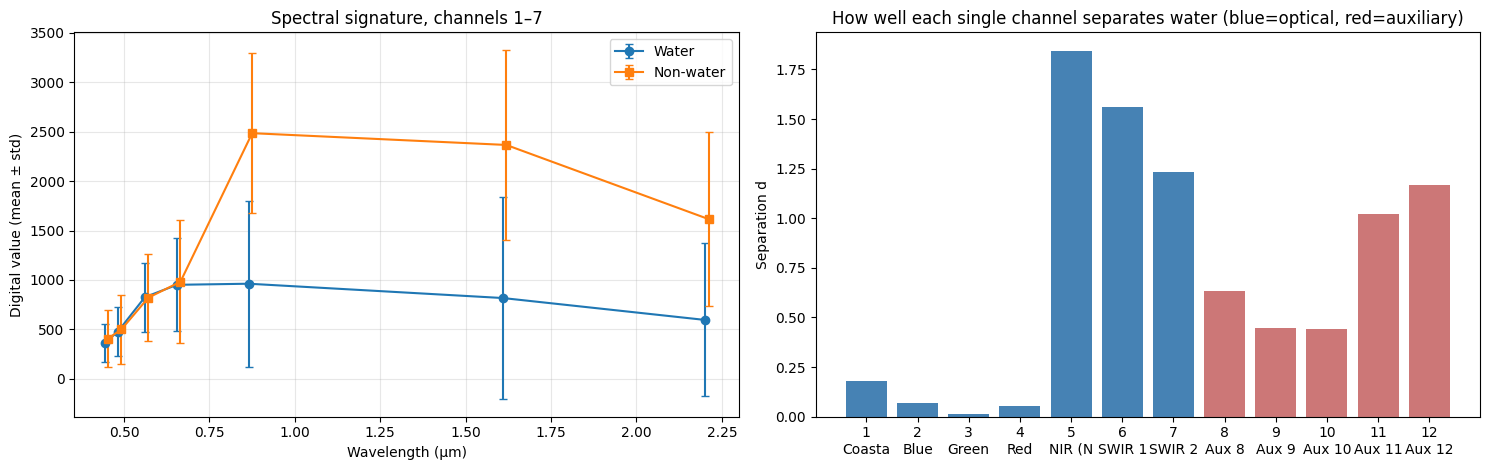

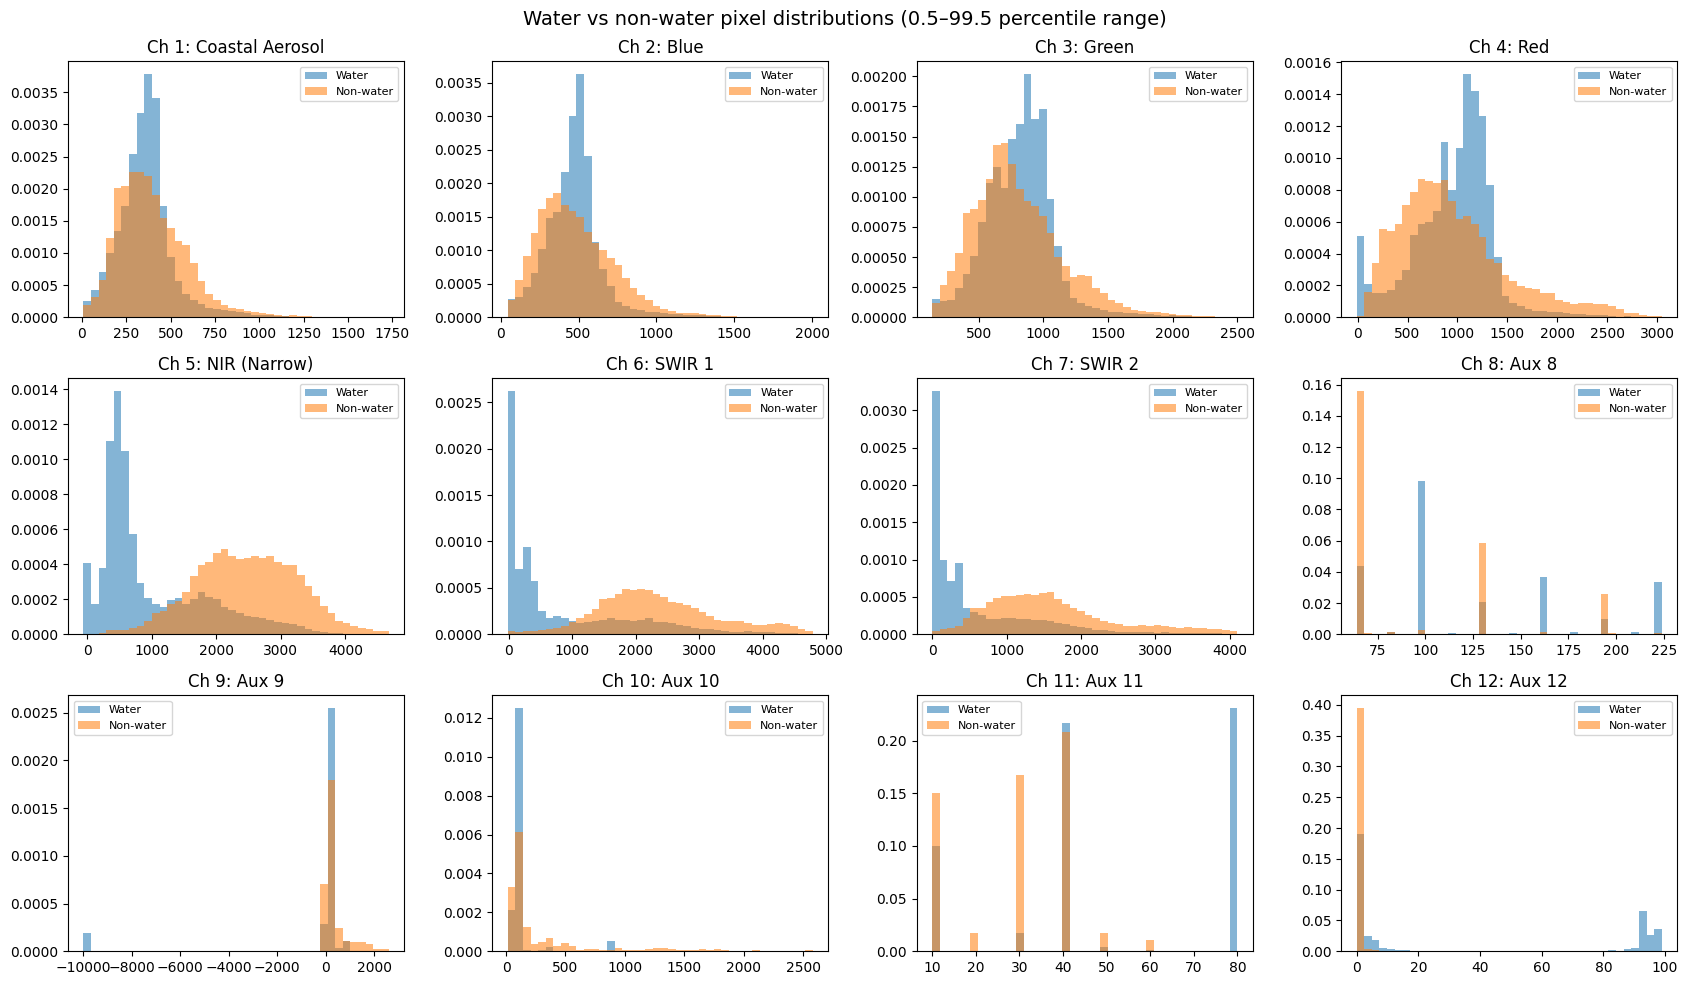

In [ ]:
centers = np.array([0.443, 0.482, 0.561, 0.655, 0.865, 1.609, 2.201])
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
ax[0].errorbar(centers, w_mean[:7], yerr=w_std[:7], marker="o", capsize=3, label="Water")
ax[0].errorbar(centers + 0.01, n_mean[:7], yerr=n_std[:7], marker="s", capsize=3, label="Non-water")
ax[0].set_xlabel("Wavelength (µm)"); ax[0].set_ylabel("Digital value (mean ± std)")
ax[0].set_title("Spectral signature, channels 1–7"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].bar([f"{c+1}\n{short[c][:6]}" for c in range(NUM_CHANNELS)], sep, color=["steelblue"]*7 + ["#c77"]*5)
ax[1].set_ylabel("Separation d"); ax[1].set_title("How well each single channel separates water (blue=optical, red=auxiliary)")
plt.tight_layout(); plt.show()

SEED = 42
rng = np.random.default_rng(SEED)
wi = rng.choice(np.where(flat_y)[0], min(40000, flat_y.sum()), replace=False)
ni = rng.choice(np.where(~flat_y)[0], min(40000, (~flat_y).sum()), replace=False)
fig, axes = plt.subplots(3, 4, figsize=(17, 10))
for c, ax in enumerate(axes.flat):
    lo, hi = np.percentile(flat_X[c], [0.5, 99.5])
    ax.hist(flat_X[c, wi], bins=40, range=(lo, hi), alpha=.55, density=True, label="Water")
    ax.hist(flat_X[c, ni], bins=40, range=(lo, hi), alpha=.55, density=True, label="Non-water")
    ax.set_title(f"Ch {c+1}: {short[c]}"); ax.legend(fontsize=8)
plt.suptitle("Water vs non-water pixel distributions (0.5–99.5 percentile range)", fontsize=14)
plt.tight_layout(); plt.show()

## 4. Feature engineering: spectral water indices


| Index | Formula | Idea |
|---|---|---|
| NDWI (McFeeters) | (Green − NIR) / (Green + NIR) | water absorbs NIR, reflects green |
| MNDWI (Xu) | (Green − SWIR1) / (Green + SWIR1) | SWIR1 suppresses built-up noise better than NIR |
| NDVI | (NIR − Red) / (NIR + Red) | vegetation indicator, helps the network rule out vegetated land |
| AWEInsh (Feyisa) | 4(Green − SWIR1) − (0.25 NIR + 2.75 SWIR2) | automated water extraction, urban/no-shadow variant |
| AWEIsh (Feyisa) | Blue + 2.5 Green − 1.5 (NIR + SWIR1) − 0.25 SWIR2 | automated water extraction, shadow-suppressing variant |

Band mapping (0-based): Blue=1, Green=2, Red=3, NIR=4, SWIR1=5, SWIR2=6.

In [ ]:
EPS = 1e-6
B_BLUE, B_GREEN, B_RED, B_NIR, B_SWIR1, B_SWIR2 = 1, 2, 3, 4, 5, 6
INDEX_NAMES = ["NDWI", "MNDWI", "NDVI", "AWEInsh", "AWEIsh"]

def normalized_difference(a, b):
    den = a + b
    out = np.zeros_like(a, dtype=np.float32)
    np.divide(a - b, den, out=out, where=np.abs(den) > EPS)
    return np.clip(out, -1.0, 1.0)

def compute_indices(img):
    band = lambda i: img[..., i, :, :]
    blue, green, red, nir, swir1, swir2 = (band(i) for i in (B_BLUE, B_GREEN, B_RED, B_NIR, B_SWIR1, B_SWIR2))
    return {
        "NDWI":    normalized_difference(green, nir),
        "MNDWI":   normalized_difference(green, swir1),
        "NDVI":    normalized_difference(nir, red),
        "AWEInsh": 4 * (green - swir1) - (0.25 * nir + 2.75 * swir2),
        "AWEIsh":  blue + 2.5 * green - 1.5 * (nir + swir1) - 0.25 * swir2,
    }

def build_features(X):
    idx = compute_indices(X)
    eng = np.stack([idx[n] for n in INDEX_NAMES], axis=-3).astype(np.float32)
    return np.concatenate([X, eng], axis=-3).astype(np.float32)

RAW_NAMES     = [f"Ch{i+1}_{short[i]}" for i in range(NUM_CHANNELS)]
FEATURE_NAMES = RAW_NAMES + INDEX_NAMES
X_eng = build_features(X_raw)
FEATURES = {"raw": X_raw, "engineered": X_eng}
print("Raw stack:", X_raw.shape, "| Engineered stack:", X_eng.shape)
assert X_eng.shape[1] == len(FEATURE_NAMES)

Raw stack: (306, 12, 128, 128) | Engineered stack: (306, 17, 128, 128)


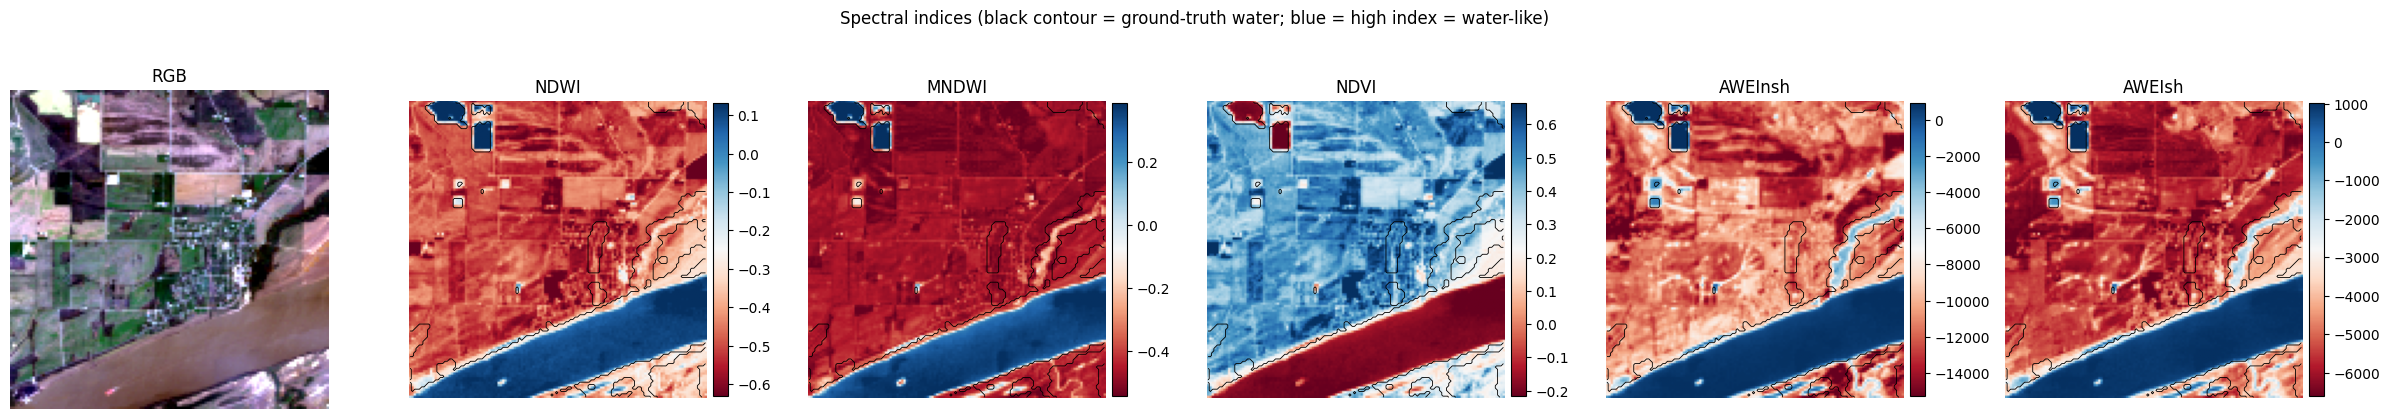

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(24, 4.3))
axes[0].imshow(composite(img, TRUE_COLOR)); axes[0].set_title("RGB")
for ax, n in zip(axes[1:], INDEX_NAMES):
    v = X_eng[rep, NUM_CHANNELS + INDEX_NAMES.index(n)]
    lo, hi = np.percentile(v, [2, 98])
    im = ax.imshow(v, cmap="RdBu", vmin=lo, vmax=hi)
    ax.contour(msk, levels=[0.5], colors="k", linewidths=0.6)
    ax.set_title(n); plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
for a in axes: a.axis("off")
plt.suptitle("Spectral indices (black contour = ground-truth water; blue = high index = water-like)", y=1.02)
plt.tight_layout(); plt.show()

,Feature,AUC,Water is
0,MNDWI,0.901,higher
1,AWEIsh,0.900,higher
2,NDWI,0.894,higher
3,Ch5_NIR (Narrow),0.892,lower
4,AWEInsh,0.862,higher
5,Ch6_SWIR 1,0.860,lower
6,NDVI,0.848,lower
7,Ch7_SWIR 2,0.840,lower
8,Ch12_Aux 12,0.808,higher
9,Ch11_Aux 11,0.743,higher


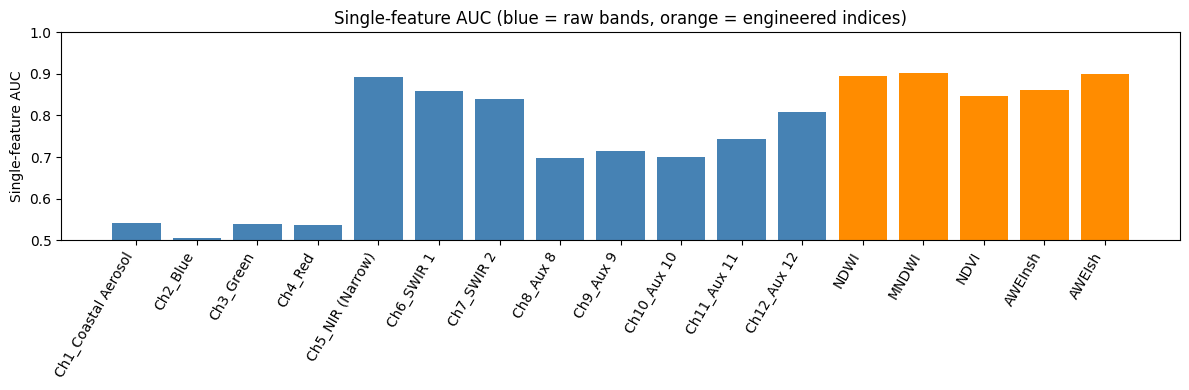

OK: band mapping is consistent (AUC NDWI=0.89, MNDWI=0.90; water = higher index, as expected).


In [ ]:
flat_F = X_eng.transpose(1, 0, 2, 3).reshape(len(FEATURE_NAMES), -1)
auc_f = np.array([roc_auc_score(flat_y, flat_F[k]) for k in range(len(FEATURE_NAMES))])
feat_table = pd.DataFrame({"Feature": FEATURE_NAMES, "AUC": np.maximum(auc_f, 1 - auc_f),
                           "Water is": np.where(auc_f > 0.5, "higher", "lower")}).round(3)
display(feat_table.sort_values("AUC", ascending=False).reset_index(drop=True))

plt.figure(figsize=(12, 4))
plt.bar(FEATURE_NAMES, feat_table["AUC"], color=["steelblue"]*NUM_CHANNELS + ["darkorange"]*len(INDEX_NAMES))
plt.xticks(rotation=60, ha="right"); plt.ylim(0.5, 1.0); plt.ylabel("Single-feature AUC")
plt.title("Single-feature AUC (blue = raw bands, orange = engineered indices)"); plt.tight_layout(); plt.show()

auc_map = dict(zip(FEATURE_NAMES, auc_f))
if min(auc_map["NDWI"], auc_map["MNDWI"]) > 0.80:
    print(f"OK: band mapping is consistent (AUC NDWI={auc_map['NDWI']:.2f}, MNDWI={auc_map['MNDWI']:.2f}; water = higher index, as expected).")
else:
    print("WARNING: NDWI/MNDWI do not separate water as expected -> the Green/NIR/SWIR band order assumed in §3 is probably wrong. Re-check BAND_INFO.")

## Normalization



In [ ]:
class ChannelNormalizer:
    def __init__(self, clip_q=(0.5, 99.5)):
        self.clip_q = clip_q

    def fit(self, X):
        C = X.shape[1]
        flat = X.transpose(1, 0, 2, 3).reshape(C, -1)
        q = np.percentile(flat, self.clip_q, axis=1)
        self.lo, self.hi = q[0], q[1]
        clipped = np.clip(flat, self.lo[:, None], self.hi[:, None])
        self.mean = clipped.mean(1)
        self.std = clipped.std(1)
        self.std[self.std < 1e-6] = 1.0
        return self

    def transform(self, X):
        v = lambda a: a.reshape(1, -1, 1, 1)
        return ((np.clip(X, v(self.lo), v(self.hi)) - v(self.mean)) / v(self.std)).astype(np.float32)

    def to_dict(self):
        return dict(lo=self.lo, hi=self.hi, mean=self.mean, std=self.std, clip_q=self.clip_q)

    @classmethod
    def from_dict(cls, d):
        o = cls(d["clip_q"]); o.lo, o.hi, o.mean, o.std = d["lo"], d["hi"], d["mean"], d["std"]
        return o

In [ ]:
order = np.argsort(frac); pick = [order[0], order[len(order)//2], order[-1]]
demo = ChannelNormalizer().fit(X_raw)
rows = []
for i in pick:
    nir = X_raw[i:i+1]
    ds_wise = demo.transform(nir)[0, B_NIR]
    im_wise = (X_raw[i, B_NIR] - X_raw[i, B_NIR].mean()) / (X_raw[i, B_NIR].std() + 1e-6)
    rows.append({"image": df.id[i], "water %": round(100*frac[i], 1),
                 "NIR mean, dataset-wise": round(float(ds_wise.mean()), 3),
                 "NIR mean, image-wise": round(float(im_wise.mean()), 3)})
display(pd.DataFrame(rows))
print("Dataset-wise keeps the physical signal (a water-dominated scene has a low NIR mean); image-wise forces every image to mean 0 and destroys it.")

N_FOLDS = 5
_strat = pd.qcut(pd.Series(frac).rank(method="first"), q=3, labels=False).values
_tr, _va = next(iter(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(np.arange(N), _strat)))
nm = ChannelNormalizer().fit(X_eng[_tr])
Ztr, Zva = nm.transform(X_eng[_tr]), nm.transform(X_eng[_va])
chk = pd.DataFrame({"feature": FEATURE_NAMES,
                    "train mean": Ztr.mean((0, 2, 3)), "train std": Ztr.std((0, 2, 3)),
                    "held-out mean": Zva.mean((0, 2, 3)), "held-out std": Zva.std((0, 2, 3))}).round(3)
display(chk)
assert np.abs(chk["train mean"]).max() < 1e-3 and np.abs(chk["train std" ] - 1).max() < 1e-2
print("Training images: every channel has mean≈0, std≈1. Held-out images differ a bit, as expected for unseen scenes (no leakage).")

,image,water %,"NIR mean, dataset-wise","NIR mean, image-wise"
0,304,0.0,1.057,-0.0
1,199,16.5,0.571,-0.0
2,215,100.0,-2.028,0.0


Dataset-wise keeps the physical signal (a water-dominated scene has a low NIR mean); image-wise forces every image to mean 0 and destroys it.


,feature,train mean,train std,held-out mean,held-out std
0,Ch1_Coastal Aerosol,-0.0,1.0,0.035,0.858
1,Ch2_Blue,0.0,1.0,0.018,0.879
2,Ch3_Green,-0.0,1.0,0.036,0.956
3,Ch4_Red,0.0,1.0,0.089,0.993
4,Ch5_NIR (Narrow),0.0,1.0,-0.072,0.960
5,Ch6_SWIR 1,-0.0,1.0,0.014,1.027
6,Ch7_SWIR 2,0.0,1.0,0.054,1.063
7,Ch8_Aux 8,0.0,1.0,-0.044,0.953
8,Ch9_Aux 9,0.0,1.0,0.068,0.213
9,Ch10_Aux 10,0.0,1.0,-0.190,0.656


Training images: every channel has mean≈0, std≈1. Held-out images differ a bit, as expected for unseen scenes (no leakage).


## Cross-validation folds


In [ ]:
strat = pd.qcut(pd.Series(frac).rank(method="first"), q=3, labels=False).values
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(np.arange(N), strat))
display(pd.DataFrame([{"fold": k, "train images": len(tr), "held-out images": len(va),
                       "held-out ids": df.id.values[va].tolist(),
                       "held-out water %": round(100 * Y[va].mean(), 1)} for k, (tr, va) in enumerate(folds)]))

,fold,train images,held-out images,held-out ids,held-out water %
0,0,244,62,"[4, 6, 16, 19, 30, 36, 39, 42, 44, 48, 56, 64,...",27.200001
1,1,245,61,"[0, 2, 15, 23, 24, 26, 29, 33, 46, 47, 55, 62,...",24.100000
2,2,245,61,"[9, 10, 20, 25, 27, 34, 35, 38, 40, 43, 45, 51...",25.600000
3,3,245,61,"[1, 3, 7, 8, 12, 13, 14, 21, 22, 32, 52, 54, 5...",26.000000
4,4,245,61,"[5, 11, 17, 18, 28, 31, 37, 41, 49, 50, 53, 57...",27.000000


U-Net

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class DoubleConv(nn.Module):
    def __init__(self, cin, cout, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                  nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True)]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels, base=32, dropout=0.0):
        super().__init__()
        c = [base, base * 2, base * 4, base * 8, base * 16]
        self.enc = nn.ModuleList([DoubleConv(in_channels, c[0]), DoubleConv(c[0], c[1]),
                                  DoubleConv(c[1], c[2]), DoubleConv(c[2], c[3], dropout)])
        self.bottleneck = DoubleConv(c[3], c[4], dropout)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.ModuleList([nn.ConvTranspose2d(c[4], c[3], 2, stride=2), nn.ConvTranspose2d(c[3], c[2], 2, stride=2),
                                 nn.ConvTranspose2d(c[2], c[1], 2, stride=2), nn.ConvTranspose2d(c[1], c[0], 2, stride=2)])
        self.dec = nn.ModuleList([DoubleConv(c[3] * 2, c[3], dropout), DoubleConv(c[2] * 2, c[2]),
                                  DoubleConv(c[1] * 2, c[1]), DoubleConv(c[0] * 2, c[0])])
        self.head = nn.Conv2d(c[0], 1, 1)

    def forward(self, x):
        skips = []
        for i, blk in enumerate(self.enc):
            x = blk(x) if i == 0 else blk(self.pool(x))
            skips.append(x)
        x = self.bottleneck(self.pool(x))
        for up, dec, skip in zip(self.up, self.dec, reversed(skips)):
            x = dec(torch.cat([up(x), skip], dim=1))
        return self.head(x)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

class BCEDiceLoss(nn.Module):
    def __init__(self, w_bce=0.5, w_dice=0.5, smooth=1.0):
        super().__init__()
        self.bce, self.w_bce, self.w_dice, self.smooth = nn.BCEWithLogitsLoss(), w_bce, w_dice, smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits)
        inter = (p * targets).sum()
        dice = 1 - (2 * inter + self.smooth) / (p.sum() + targets.sum() + self.smooth)
        return self.w_bce * self.bce(logits, targets) + self.w_dice * dice

def counts(probs, Yt, thr):
    pred, gt = probs >= thr, Yt > 0.5
    return ((pred & gt).sum((1, 2)).astype(np.int64), (pred & ~gt).sum((1, 2)).astype(np.int64),
            (~pred & gt).sum((1, 2)).astype(np.int64), (~pred & ~gt).sum((1, 2)).astype(np.int64))

def metrics_from_counts(tp, fp, fn, tn):
    e = 1e-9
    iou = tp / (tp + fp + fn + e); prec = tp / (tp + fp + e); rec = tp / (tp + fn + e)
    f1 = 2 * prec * rec / (prec + rec + e)
    return dict(IoU=float(iou), Precision=float(prec), Recall=float(rec), F1=float(f1))

def pooled_metrics(probs, Yt, thr=0.5):
    tp, fp, fn, tn = counts(probs, Yt, thr)
    return metrics_from_counts(tp.sum(), fp.sum(), fn.sum(), tn.sum())

_m = UNet(len(FEATURE_NAMES), base=16, dropout=0.1).to(DEVICE).eval()
with torch.no_grad():
    assert _m(torch.randn(2, len(FEATURE_NAMES), 128, 128, device=DEVICE)).shape == (2, 1, 128, 128)
print(f"U-Net OK | params: base32/12ch={count_params(UNet(12,32)):,} | base32/{len(FEATURE_NAMES)}ch={count_params(UNet(len(FEATURE_NAMES),32)):,} | base16/{len(FEATURE_NAMES)}ch={count_params(UNet(len(FEATURE_NAMES),16)):,}")
del _m

U-Net OK | params: base32/12ch=7,765,633 | base32/17ch=7,767,073 | base16/17ch=1,944,593


In [ ]:
class SegDataset(Dataset):
    def __init__(self, X, Yt, augment=False, noise_std=0.0):
        self.X, self.Y = torch.from_numpy(X), torch.from_numpy(Yt)[:, None]
        self.augment, self.noise_std = augment, noise_std
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        x, y = self.X[i], self.Y[i]
        if self.augment:
            k = random.randint(0, 3)
            x, y = torch.rot90(x, k, (1, 2)), torch.rot90(y, k, (1, 2))
            if random.random() < 0.5:
                x, y = torch.flip(x, (2,)), torch.flip(y, (2,))
            if self.noise_std > 0:
                x = x + self.noise_std * torch.randn_like(x)
        return x.contiguous(), y.contiguous()

@torch.no_grad()
def tta_forward(model, xb):
    acc = 0
    for k in range(4):
        for flip in (False, True):
            x = torch.rot90(xb, k, (2, 3))
            if flip: x = torch.flip(x, (3,))
            p = torch.sigmoid(model(x))
            if flip: p = torch.flip(p, (3,))
            acc = acc + torch.rot90(p, -k, (2, 3))
    return acc / 8

@torch.no_grad()
def predict_proba(model, X, tta=False, bs=16):
    model.eval(); out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i + bs]).to(DEVICE)
        p = tta_forward(model, xb) if tta else torch.sigmoid(model(xb))
        out.append(p[:, 0].cpu().numpy())
    return np.concatenate(out)

@torch.no_grad()
def eval_loss_probs(model, X, Yt, criterion, bs=16):
    model.eval(); total, probs = 0.0, []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i + bs]).to(DEVICE)
        yb = torch.from_numpy(Yt[i:i + bs])[:, None].to(DEVICE)
        logits = model(xb)
        total += criterion(logits, yb).item() * len(xb)
        probs.append(torch.sigmoid(logits)[:, 0].cpu().numpy())
    return total / len(X), np.concatenate(probs)

def train_one(cfg, Xtr, Ytr, Xva, Yva, seed, verbose=True, tag=""):
    set_seed(seed)
    model = UNet(Xtr.shape[1], base=cfg["base"], dropout=cfg["dropout"]).to(DEVICE)
    ds = SegDataset(Xtr, Ytr, augment=True, noise_std=cfg["noise"])
    sampler = RandomSampler(ds, replacement=True, num_samples=STEPS_PER_EPOCH * BATCH_SIZE)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, drop_last=True)
    criterion = BCEDiceLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=MAX_LR, total_steps=EPOCHS * len(loader), pct_start=0.2)
    hist = []
    for epoch in range(1, EPOCHS + 1):
        model.train(); run, n = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
            run += loss.item() * len(xb); n += len(xb)
        vloss, vprob = eval_loss_probs(model, Xva, Yva, criterion)
        vm = pooled_metrics(vprob, Yva, 0.5)
        hist.append(dict(epoch=epoch, train_loss=run / n, val_loss=vloss, val_iou=vm["IoU"], val_f1=vm["F1"]))
        if verbose and (epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS):
            print(f"  {tag} epoch {epoch:03d} | train loss {run/n:.4f} | val loss {vloss:.4f} | val IoU {vm['IoU']:.4f} | val F1 {vm['F1']:.4f}")
    return model, pd.DataFrame(hist)

## Training



In [ ]:
BATCH_SIZE = 8
STEPS_PER_EPOCH = 32
EPOCHS = 15
MAX_LR = 1e-3
WEIGHT_DECAY = 1e-4

OUT_DIR = Path("/content/drive/MyDrive")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

CONFIGS = {
    "A_baseline_12ch":        dict(features="raw",        base=32, dropout=0.00, noise=0.00, tta=False),
    "B_engineered":           dict(features="engineered", base=32, dropout=0.00, noise=0.00, tta=False),
    "C_engineered_optimized": dict(features="engineered", base=16, dropout=0.15, noise=0.03, tta=True),
}

oof_probs, fold_rows, histories, artifacts = {}, [], {}, {}
t_start = time.time()

for name, cfg in CONFIGS.items():
    Xf = FEATURES[cfg["features"]]
    oof_main = np.zeros(Y.shape, np.float32)
    oof_plain = np.zeros(Y.shape, np.float32) if cfg["tta"] else None
    histories[name], artifacts[name] = [], []
    print(f"\n=== {name}  ({Xf.shape[1]} input channels, base={cfg['base']}, dropout={cfg['dropout']}, TTA={cfg['tta']}) ===")

    for k, (tr, va) in enumerate(folds):
        norm = ChannelNormalizer().fit(Xf[tr])
        Xtr, Xva = norm.transform(Xf[tr]), norm.transform(Xf[va])
        t0 = time.time()
        model, hist = train_one(cfg, Xtr, Y[tr], Xva, Y[va], seed=SEED + k, tag=f"[fold {k}]")

        p_plain = predict_proba(model, Xva, tta=False)
        p_main = predict_proba(model, Xva, tta=True) if cfg["tta"] else p_plain
        oof_main[va] = p_main
        if cfg["tta"]: oof_plain[va] = p_plain

        vm = pooled_metrics(p_main, Y[va], 0.5)
        tm = pooled_metrics(predict_proba(model, Xtr), Y[tr], 0.5)
        fold_rows.append(dict(config=name, fold=k, n_val=len(va), val_IoU=vm["IoU"], val_F1=vm["F1"],
                              val_Precision=vm["Precision"], val_Recall=vm["Recall"], train_IoU=tm["IoU"]))
        histories[name].append(hist)
        artifacts[name].append(dict(state={a: b.detach().cpu().clone() for a, b in model.state_dict().items()}, norm=norm.to_dict()))
        print(f"  >> fold {k}: validation IoU at end of training = {vm['IoU']:.4f} | F1 = {vm['F1']:.4f} "
              f"| P = {vm['Precision']:.3f} | R = {vm['Recall']:.3f} | train IoU = {tm['IoU']:.4f} | {time.time()-t0:.0f}s")
        del model
        if DEVICE.type == "cuda": torch.cuda.empty_cache()

    oof_probs[name] = oof_main
    if cfg["tta"]:
        oof_probs[name + " (no TTA)"] = oof_plain

fold_df = pd.DataFrame(fold_rows)
print(f"\nTotal CV time: {(time.time()-t_start)/60:.1f} min")


=== A_baseline_12ch  (12 input channels, base=32, dropout=0.0, TTA=False) ===
  [fold 0] epoch 001 | train loss 0.5635 | val loss 0.4071 | val IoU 0.6563 | val F1 0.7925
  [fold 0] epoch 010 | train loss 0.2452 | val loss 0.2206 | val IoU 0.7178 | val F1 0.8357
  [fold 0] epoch 015 | train loss 0.2322 | val loss 0.2070 | val IoU 0.7021 | val F1 0.8250
  >> fold 0: validation IoU at end of training = 0.7021 | F1 = 0.8250 | P = 0.934 | R = 0.739 | train IoU = 0.7013 | 41s
  [fold 1] epoch 001 | train loss 0.5591 | val loss 0.4462 | val IoU 0.5954 | val F1 0.7464
  [fold 1] epoch 010 | train loss 0.2491 | val loss 0.2452 | val IoU 0.6703 | val F1 0.8026
  [fold 1] epoch 015 | train loss 0.2376 | val loss 0.2365 | val IoU 0.6660 | val F1 0.7995
  >> fold 1: validation IoU at end of training = 0.6660 | F1 = 0.7995 | P = 0.911 | R = 0.712 | train IoU = 0.7241 | 37s
  [fold 2] epoch 001 | train loss 0.6036 | val loss 0.4539 | val IoU 0.6438 | val F1 0.7833
  [fold 2] epoch 010 | train loss 0

,config,fold,n_val,val_IoU,val_F1,val_Precision,val_Recall,train_IoU
0,A_baseline_12ch,0,62,0.7021,0.8250,0.9339,0.7388,0.7013
1,A_baseline_12ch,1,61,0.6660,0.7995,0.9113,0.7121,0.7241
2,A_baseline_12ch,2,61,0.6954,0.8203,0.8950,0.7572,0.7132
3,A_baseline_12ch,3,61,0.6867,0.8142,0.7298,0.9208,0.6943
4,A_baseline_12ch,4,61,0.6963,0.8209,0.8753,0.7729,0.7236
5,B_engineered,0,62,0.7193,0.8367,0.9173,0.7692,0.7119
6,B_engineered,1,61,0.6724,0.8041,0.9040,0.7242,0.7311
7,B_engineered,2,61,0.7074,0.8287,0.8743,0.7875,0.7218
8,B_engineered,3,61,0.7411,0.8513,0.8310,0.8726,0.7146
9,B_engineered,4,61,0.6846,0.8128,0.8707,0.7621,0.7165


val_IoU          val_F1         val_Precision          \
                          mean     std    mean     std          mean     std   
config                                                                         
A_baseline_12ch         0.6893  0.0141  0.8160  0.0100        0.8691  0.0808   
B_engineered            0.7050  0.0273  0.8267  0.0188        0.8794  0.0335   
C_engineered_optimized  0.7034  0.0389  0.8254  0.0270        0.8781  0.0314   

                       val_Recall         train_IoU          
                             mean     std      mean     std  
config                                                       
A_baseline_12ch            0.7804  0.0817    0.7113  0.0133  
B_engineered               0.7831  0.0551    0.7192  0.0076  
C_engineered_optimized     0.7823  0.0622    0.7130  0.0062

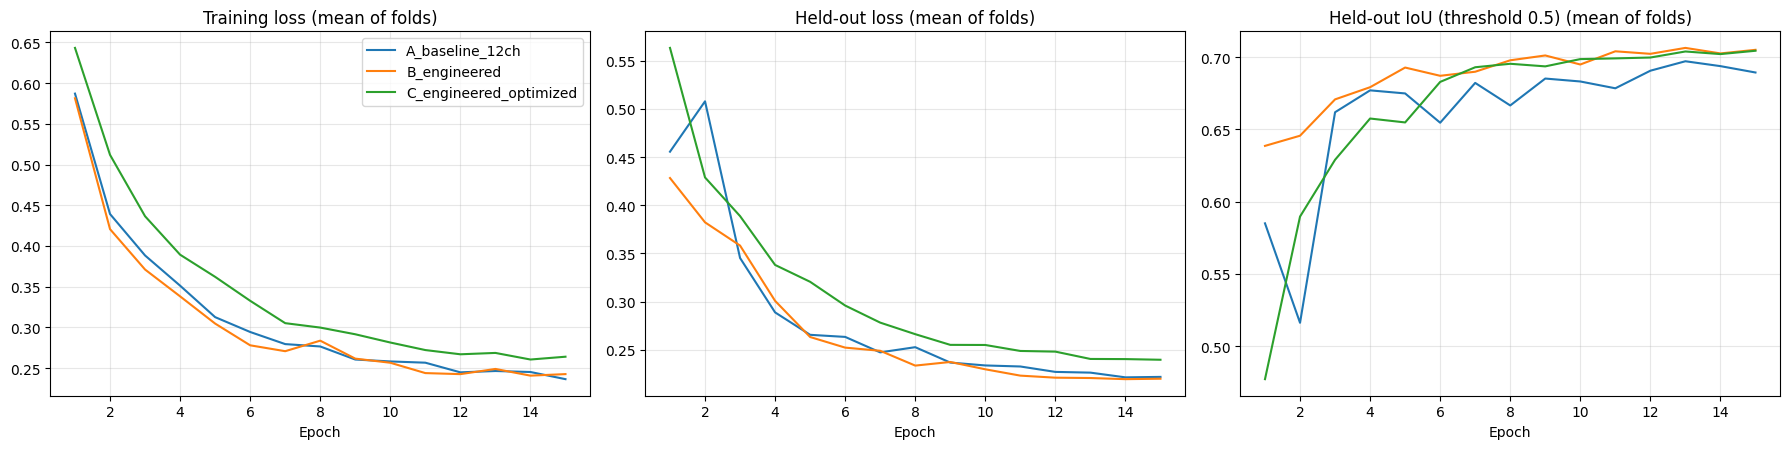

In [ ]:
display(fold_df.round(4))
agg = fold_df.groupby("config")[["val_IoU", "val_F1", "val_Precision", "val_Recall", "train_IoU"]].agg(["mean", "std"]).round(4)
display(agg)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.6))
for name in CONFIGS:
    H = pd.concat(histories[name]).groupby("epoch").mean()
    ax[0].plot(H.index, H.train_loss, label=name); ax[1].plot(H.index, H.val_loss, label=name); ax[2].plot(H.index, H.val_iou, label=name)
for a, t in zip(ax, ["Training loss", "Held-out loss", "Held-out IoU (threshold 0.5)"]):
    a.set_title(t + " (mean of folds)"); a.set_xlabel("Epoch"); a.grid(alpha=.3)
ax[0].legend(); plt.tight_layout(); plt.show()

## Results



In [ ]:
def label_cfg(label):
    return CONFIGS[label.replace(" (no TTA)", "")]

def oof_summary_row(label, probs, thr=0.5):
    m = pooled_metrics(probs, Y, thr)
    tp, fp, fn, tn = counts(probs, Y, thr)
    per_img = np.where(tp + fp + fn == 0, 1.0, tp / (tp + fp + fn + 1e-9))
    cfg = label_cfg(label)
    return dict(Config=label, Channels=FEATURES[cfg["features"]].shape[1], Base=cfg["base"],
                IoU=m["IoU"], Precision=m["Precision"], Recall=m["Recall"], F1=m["F1"],
                **{"Mean per-image IoU": per_img.mean(), "Worst image IoU": per_img.min()})

summary = pd.DataFrame([oof_summary_row(l, p, 0.5) for l, p in oof_probs.items()])
display(summary.round(4))

cands = [n for n in CONFIGS if CONFIGS[n]["features"] == "engineered"]
FINAL_NAME = max(cands, key=lambda n: summary.set_index("Config").loc[n, "IoU"])
FINAL_CFG = CONFIGS[FINAL_NAME]
print("Final model:", FINAL_NAME)

,Config,Channels,Base,IoU,Precision,Recall,F1,Mean per-image IoU,Worst image IoU
0,A_baseline_12ch,12,32,0.6897,0.8552,0.7809,0.8164,0.5945,0.0
1,B_engineered,17,32,0.7060,0.8769,0.7836,0.8276,0.6078,0.0
2,C_engineered_optimized,17,16,0.7051,0.8751,0.7840,0.8271,0.6016,0.0
3,C_engineered_optimized (no TTA),17,16,0.7061,0.8753,0.7850,0.8277,0.6012,0.0


Final model: B_engineered
